In [1]:
# Step 1 — imports

from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

print("Imports loaded.")

Imports loaded.


In [2]:
# Step 2 — load clean observed-return cohort

DATA_DIR = Path("../data")

stage2 = pd.read_csv(
    DATA_DIR / "stage2_rtp_observed.csv"
)

print("Shape:", stage2.shape)

print("\nColumns:")
print(stage2.columns.tolist())

print("\nPlayers:")
print(
    stage2[
        [
            "player",
            "season",
            "start_week",
            "games_missed"
        ]
    ]
    .sort_values(["season", "start_week"])
    .to_string(index=False)
)

Shape: (8, 40)

Columns:
['injury_id_2wk', 'player', 'gsis_id', 'season', 'start_week', 'last_report_week', 'report_rows', 'initial_practice_status', 'initial_report_status', 'stat_weeks', 'team', 'team_game_weeks', 'injury_game_weeks', 'first_game_back', 'games_missed', 'weeks_to_return', 'missed_game_weeks', 'rtp_status', 'validated_outcome', 'validated_return_week', 'validation_reason', 'final_rtp_outcome', 'eligible_missed_game_model', 'eligible_rtp_duration_model', 'has_schedule_coverage', 'missed_game_target', 'rtp_week', 'rtp_games_missed', 'injury_grade', 'injury_severity', 'severity_source', 'severity_notes', 'reported_grade', 'reported_severity', 'severity_evidence', 'source_quality', 'source', 'notes', 'severity_group', 'injury_classification_flag']

Players:
         player  season  start_week  games_missed
   Michael Vick    2013           6             5
     Jay Cutler    2015           3             1
 Marcus Mariota    2017           5             1
   Daniel Jones    

In [3]:
# Step 3 — verify Stage 2 target

stage2["rtp_games_missed"] = (
    stage2["games_missed"]
    .astype("Int64")
)

print("Missing RTP targets:", stage2["rtp_games_missed"].isna().sum())

print("\nGames-missed distribution:")
print(
    stage2["rtp_games_missed"]
    .value_counts()
    .sort_index()
)

print("\nRTP summary:")
print(
    stage2["rtp_games_missed"]
    .describe()
    .round(3)
)

print(
    "\nMedian games missed:",
    stage2["rtp_games_missed"].median()
)

Missing RTP targets: 0

Games-missed distribution:
rtp_games_missed
1    5
2    2
5    1
Name: count, dtype: Int64

RTP summary:
count      8.0
mean      1.75
std      1.389
min        1.0
25%        1.0
50%        1.0
75%        2.0
max        5.0
Name: rtp_games_missed, dtype: Float64

Median games missed: 1.0


In [4]:
# Step 4 — inspect severity information in Stage 2 cohort

severity_cols = [
    "reported_grade",
    "reported_severity",
    "severity_evidence",
    "source_quality",
    "source",
    "notes"
]

print("Severity columns present:")
for col in severity_cols:
    print(f"{col}: {col in stage2.columns}")

print("\nStage 2 severity information:")

available_severity_cols = [
    col for col in severity_cols
    if col in stage2.columns
]

print(
    stage2[
        [
            "player",
            "season",
            "rtp_games_missed"
        ] + available_severity_cols
    ]
    .sort_values(["season", "player"])
    .to_string(index=False)
)

Severity columns present:
reported_grade: True
reported_severity: True
severity_evidence: True
source_quality: True
source: True
notes: True

Stage 2 severity information:
         player  season  rtp_games_missed reported_grade reported_severity    severity_evidence source_quality                     source                                                                                                                                                                       notes
   Michael Vick    2013                 5            NaN   moderate/severe      clinical_detail        primary                    NFL.com      Vick said the hamstring injury was worse than initially expected and high on the leg. He later reinjured it and reported another pop. No numerical grade was reported.
     Jay Cutler    2015                 1            NaN           unknown      clinical_detail        primary                    NFL.com Cutler left the game against Arizona with a hamstring injury and did n

In [5]:
# Step 5 — identify cases with documented severity evidence

if "severity_evidence" in stage2.columns:

    documented_severity = stage2[
        stage2["severity_evidence"].notna()
        &
        (stage2["severity_evidence"] != "unknown")
    ].copy()

    print(
        "Stage 2 cases with documented severity:",
        len(documented_severity)
    )

    print(
        documented_severity[
            [
                "player",
                "season",
                "reported_grade",
                "reported_severity",
                "severity_evidence",
                "rtp_games_missed"
            ]
        ]
        .sort_values(["rtp_games_missed", "season"])
        .to_string(index=False)
    )

else:
    print(
        "Severity fields are not present in stage2_rtp_observed.csv."
    )

Stage 2 cases with documented severity: 8
         player  season reported_grade reported_severity    severity_evidence  rtp_games_missed
     Jay Cutler    2015            NaN           unknown      clinical_detail                 1
 Marcus Mariota    2017            NaN              mild severity_description                 1
 Russell Wilson    2022        Grade 2          moderate       explicit_grade                 1
Taylor Heinicke    2023            NaN           unknown      clinical_detail                 1
  Justin Fields    2024            NaN           unknown      clinical_detail                 1
   Daniel Jones    2020        Grade 2          moderate       explicit_grade                 2
   Kyler Murray    2022        Grade 2          moderate       explicit_grade                 2
   Michael Vick    2013            NaN   moderate/severe      clinical_detail                 5


In [6]:
# Step 6 — create conservative severity categories for comparison

stage2["comparison_severity"] = "unknown"

# Explicitly documented mild description
stage2.loc[
    stage2["reported_severity"].eq("mild"),
    "comparison_severity"
] = "mild"

# Explicit Grade 2 / moderate cases
stage2.loc[
    (
        stage2["reported_grade"].eq("Grade 2")
        |
        stage2["reported_severity"].eq("moderate")
    ),
    "comparison_severity"
] = "moderate"

print(
    stage2[
        [
            "player",
            "season",
            "reported_grade",
            "reported_severity",
            "severity_evidence",
            "comparison_severity",
            "rtp_games_missed"
        ]
    ]
    .sort_values(["comparison_severity", "season"])
    .to_string(index=False)
)

print("\nComparison severity counts:")
print(stage2["comparison_severity"].value_counts())

         player  season reported_grade reported_severity    severity_evidence comparison_severity  rtp_games_missed
 Marcus Mariota    2017            NaN              mild severity_description                mild                 1
   Daniel Jones    2020        Grade 2          moderate       explicit_grade            moderate                 2
 Russell Wilson    2022        Grade 2          moderate       explicit_grade            moderate                 1
   Kyler Murray    2022        Grade 2          moderate       explicit_grade            moderate                 2
   Michael Vick    2013            NaN   moderate/severe      clinical_detail             unknown                 5
     Jay Cutler    2015            NaN           unknown      clinical_detail             unknown                 1
Taylor Heinicke    2023            NaN           unknown      clinical_detail             unknown                 1
  Justin Fields    2024            NaN           unknown      clinical_d

In [7]:
# Step 7 — summarize RTP by conservative severity category

severity_summary = (
    stage2
    .groupby("comparison_severity")["rtp_games_missed"]
    .agg(
        cases="count",
        median="median",
        mean="mean",
        minimum="min",
        maximum="max"
    )
    .round(2)
    .reset_index()
)

print(severity_summary.to_string(index=False))

print("\nOverall Stage 2:")
print(f"Cases: {len(stage2)}")
print(f"Median: {stage2['rtp_games_missed'].median():.1f}")
print(f"Mean: {stage2['rtp_games_missed'].mean():.2f}")

print("\nKnown mild comparison cases:")
print(
    stage2.loc[
        stage2["comparison_severity"] == "mild",
        [
            "player",
            "season",
            "rtp_games_missed"
        ]
    ].to_string(index=False)
)

comparison_severity  cases  median  mean  minimum  maximum
               mild      1     1.0   1.0        1        1
           moderate      3     2.0  1.67        1        2
            unknown      4     1.0   2.0        1        5

Overall Stage 2:
Cases: 8
Median: 1.0
Mean: 1.75

Known mild comparison cases:
        player  season  rtp_games_missed
Marcus Mariota    2017                 1


In [8]:
# Step 8 — define Caleb Williams case information

caleb_case = {
    "player": "Caleb Williams",
    "injury": "hamstring strain",
    "reported_grade": "Grade 1",
    "comparison_severity": "mild"
}

print("Caleb Williams case:")
for key, value in caleb_case.items():
    print(f"{key}: {value}")

Caleb Williams case:
player: Caleb Williams
injury: hamstring strain
reported_grade: Grade 1
comparison_severity: mild


In [9]:
# Step 9 — create historical RTP scenario buckets

def classify_rtp_scenario(games):
    if games == 1:
        return "1 game"
    elif games == 2:
        return "2 games"
    else:
        return "3+ games"


stage2["rtp_scenario"] = (
    stage2["rtp_games_missed"]
    .apply(classify_rtp_scenario)
)

scenario_counts = (
    stage2["rtp_scenario"]
    .value_counts()
    .reindex(
        ["1 game", "2 games", "3+ games"],
        fill_value=0
    )
)

scenario_rates = scenario_counts / len(stage2)

scenario_summary = pd.DataFrame({
    "cases": scenario_counts,
    "historical_rate": scenario_rates
})

print("Historical RTP scenarios:")
print(scenario_summary)

print("\nPercentages:")
print((scenario_rates * 100).round(1))

Historical RTP scenarios:
              cases  historical_rate
rtp_scenario                        
1 game            5            0.625
2 games           2            0.250
3+ games          1            0.125

Percentages:
rtp_scenario
1 game      62.5
2 games     25.0
3+ games    12.5
Name: count, dtype: float64


In [10]:
# Step 10 — inspect historical cases by RTP scenario

scenario_cases = (
    stage2[
        [
            "player",
            "season",
            "comparison_severity",
            "rtp_games_missed",
            "rtp_scenario"
        ]
    ]
    .sort_values(
        ["rtp_games_missed", "season"]
    )
)

print(
    scenario_cases.to_string(index=False)
)

         player  season comparison_severity  rtp_games_missed rtp_scenario
     Jay Cutler    2015             unknown                 1       1 game
 Marcus Mariota    2017                mild                 1       1 game
 Russell Wilson    2022            moderate                 1       1 game
Taylor Heinicke    2023             unknown                 1       1 game
  Justin Fields    2024             unknown                 1       1 game
   Daniel Jones    2020            moderate                 2      2 games
   Kyler Murray    2022            moderate                 2      2 games
   Michael Vick    2013             unknown                 5     3+ games


In [12]:
# Step 11 — inspect Stage 1 model features needed for Caleb

stage1_features = [
    "report_out_or_doubtful",
    "pre3_total_actions_avg",
    "prior_hamstring_episodes"
]

print("Stage 1 features required for Caleb:")
for feature in stage1_features:
    print("-", feature)

print("\nHistorical feature ranges:")
# Load the Stage 1 feature table before inspecting its ranges

stage1 = None
stage1_source = None

for path in sorted(DATA_DIR.rglob("*.csv")):
    if path.name == "stage2_rtp_observed.csv":
        continue

    candidate_columns = pd.read_csv(path, nrows=0).columns
    if set(stage1_features).issubset(candidate_columns):
        stage1 = pd.read_csv(path)
        stage1_source = path
        break

if stage1 is None:
    raise FileNotFoundError(
        f"No CSV in {DATA_DIR} contains all Stage 1 features: "
        f"{stage1_features}"
    )

print("Loaded Stage 1 features from:", stage1_source)
print(
    stage1[stage1_features]
    .describe()
    .round(3)
)

Stage 1 features required for Caleb:
- report_out_or_doubtful
- pre3_total_actions_avg
- prior_hamstring_episodes

Historical feature ranges:
Loaded Stage 1 features from: ../data/stage1_engineered_features.csv
       report_out_or_doubtful  pre3_total_actions_avg  \
count                  24.000                  23.000   
mean                    0.292                  31.681   
std                     0.464                  10.957   
min                     0.000                   0.000   
25%                     0.000                  28.167   
50%                     0.000                  33.333   
75%                     1.000                  38.667   
max                     1.000                  47.667   

       prior_hamstring_episodes  
count                    24.000  
mean                      0.250  
std                       0.532  
min                       0.000  
25%                       0.000  
50%                       0.000  
75%                       0.000  
max

In [14]:
# Step 12 — check whether Caleb exists in saved player data

# Load player stat table if it is not already defined elsewhere in the notebook
if "player_stats" not in globals():
    player_stats = None

    for path in sorted(DATA_DIR.rglob("*.csv")):
        try:
            candidate = pd.read_csv(path)
        except Exception:
            continue

        if "player_display_name" in candidate.columns:
            player_stats = candidate
            print("Loaded player stats from:", path)
            break

    if player_stats is None:
        player_stats = pd.DataFrame(columns=["player_display_name"])
        print("No player_stats CSV with 'player_display_name' was found; using an empty DataFrame.")

caleb_matches = (
    player_stats.loc[
        player_stats["player_display_name"]
        .astype(str)
        .str.contains("Caleb Williams", case=False, na=False)
    ]
    .copy()
)

print("Caleb stat rows:", len(caleb_matches))

if len(caleb_matches) > 0:
    display_cols = [
        col for col in [
            "season",
            "week",
            "recent_team",
            "attempts",
            "carries"
        ]
        if col in caleb_matches.columns
    ]

    print(
        caleb_matches[display_cols]
        .sort_values(["season", "week"])
        .tail(10)
        .to_string(index=False)
    )

Loaded player stats from: ../data/raw/player_stats.csv
Caleb stat rows: 17
 season  week recent_team  attempts  carries
   2024     9         CHI        41        4
   2024    10         CHI        30        2
   2024    11         CHI        31        9
   2024    12         CHI        47        6
   2024    13         CHI        39        4
   2024    14         CHI        23        4
   2024    15         CHI        31        4
   2024    16         CHI        40        6
   2024    17         CHI        28        5
   2024    18         CHI        29        3


In [15]:
# Step 13 — inspect Caleb's complete available game history

caleb_games = (
    caleb_matches[
        [
            "season",
            "week",
            "recent_team",
            "attempts",
            "carries"
        ]
    ]
    .sort_values(["season", "week"])
    .copy()
)

caleb_games["total_actions"] = (
    caleb_games["attempts"].fillna(0)
    + caleb_games["carries"].fillna(0)
)

print(
    caleb_games.to_string(index=False)
)

 season  week recent_team  attempts  carries  total_actions
   2024     1         CHI        29        5             34
   2024     2         CHI        37        5             42
   2024     3         CHI        52        1             53
   2024     4         CHI        23        5             28
   2024     5         CHI        29        5             34
   2024     6         CHI        29        4             33
   2024     8         CHI        24        9             33
   2024     9         CHI        41        4             45
   2024    10         CHI        30        2             32
   2024    11         CHI        31        9             40
   2024    12         CHI        47        6             53
   2024    13         CHI        39        4             43
   2024    14         CHI        23        4             27
   2024    15         CHI        31        4             35
   2024    16         CHI        40        6             46
   2024    17         CHI        28     

In [16]:
# Step 14 — verify Stage 1 workload feature values

print(
    stage1[
        [
            "player",
            "season",
            "start_week",
            "pre3_total_actions_avg"
        ]
    ]
    .sort_values(["season", "start_week"])
    .to_string(index=False)
)

         player  season  start_week  pre3_total_actions_avg
    Vince Young    2009          15               34.333333
       Joe Webb    2010          14                     NaN
  David Garrard    2010          15               32.333333
     Brad Smith    2011          17                0.000000
   Michael Vick    2013           6               30.000000
 Blaine Gabbert    2013           6               31.666667
  Aaron Rodgers    2014          10               38.333333
 Johnny Manziel    2014          17               14.333333
     Jay Cutler    2015           3               26.000000
   Michael Vick    2015           7               25.000000
  Carson Palmer    2016           7               41.000000
  Aaron Rodgers    2016          13               47.666667
 Marcus Mariota    2017           5               28.666667
   Jeff Driskel    2019          13               42.333333
   Kyler Murray    2019          13               39.000000
   Kyler Murray    2019          17     

In [18]:
# Step 15 — create Caleb Stage 1 input framework

caleb_stage1 = pd.DataFrame({
    "player": ["Caleb Williams"],
    "reported_grade": ["Grade 2"],

    # Fill these only after verifying the current injury report
    "injury_start_week": [pd.NA],
    "initial_report_status": [pd.NA],

    # Final Stage 1 model features
    "report_out_or_doubtful": [pd.NA],
    "pre3_total_actions_avg": [pd.NA],
    "prior_hamstring_episodes": [pd.NA]
})

print(caleb_stage1.to_string(index=False))

        player reported_grade injury_start_week initial_report_status report_out_or_doubtful pre3_total_actions_avg prior_hamstring_episodes
Caleb Williams        Grade 2              <NA>                  <NA>                   <NA>                   <NA>                     <NA>


In [19]:
# Step 15 — create Caleb Stage 1 input framework

caleb_stage1 = pd.DataFrame({
    "player": ["Caleb Williams"],
    "injury": ["right hamstring strain"],
    "reported_grade": ["Grade 2"],
    "injury_start_week": [2],

    # Stage 1 inputs still to derive/verify
    "initial_report_status": [pd.NA],
    "report_out_or_doubtful": [pd.NA],
    "pre3_total_actions_avg": [pd.NA],
    "prior_hamstring_episodes": [pd.NA],

    # External benchmark — NOT a model feature
    "reported_recovery_timeline": ["3-4 weeks"]
})

print(caleb_stage1.to_string(index=False))

        player                 injury reported_grade  injury_start_week initial_report_status report_out_or_doubtful pre3_total_actions_avg prior_hamstring_episodes reported_recovery_timeline
Caleb Williams right hamstring strain        Grade 2                  2                  <NA>                   <NA>                   <NA>                     <NA>                  3-4 weeks


In [20]:
# Step 16 — inspect how early-season historical cases handled pre-3 workload

early_cases = stage1.loc[
    stage1["start_week"] <= 3,
    [
        "player",
        "season",
        "start_week",
        "pre3_total_actions_avg"
    ]
].copy()

print("Historical Stage 1 episodes beginning Week 3 or earlier:")
print(
    early_cases
    .sort_values(["season", "start_week"])
    .to_string(index=False)
)

print("\nNumber of early-season cases:", len(early_cases))
print(
    "Missing pre-3 workload:",
    early_cases["pre3_total_actions_avg"].isna().sum()
)

Historical Stage 1 episodes beginning Week 3 or earlier:
    player  season  start_week  pre3_total_actions_avg
Jay Cutler    2015           3                    26.0

Number of early-season cases: 1
Missing pre-3 workload: 0


In [21]:
# Step 17 — reconstruct Jay Cutler's pre-injury workload

cutler_games = (
    player_stats[
        player_stats["player_display_name"]
        .str.contains("Jay Cutler", case=False, na=False)
    ][
        [
            "season",
            "week",
            "recent_team",
            "attempts",
            "carries"
        ]
    ]
    .sort_values(["season", "week"])
    .copy()
)

cutler_games["total_actions"] = (
    cutler_games["attempts"].fillna(0)
    + cutler_games["carries"].fillna(0)
)

print(
    cutler_games[
        cutler_games["season"].isin([2014, 2015])
    ].to_string(index=False)
)

 season  week recent_team  attempts  carries  total_actions
   2014     1         CHI        49        0             49
   2014     2         CHI        34        5             39
   2014     3         CHI        38        5             43
   2014     4         CHI        34        3             37
   2014     5         CHI        36        3             39
   2014     6         CHI        38        6             44
   2014     7         CHI        34        2             36
   2014     8         CHI        30        1             31
   2014    10         CHI        37        2             39
   2014    11         CHI        43        5             48
   2014    12         CHI        27        0             27
   2014    13         CHI        48        1             49
   2014    14         CHI        46        2             48
   2014    15         CHI        31        1             32
   2014    17         CHI        36        3             39
   2015     1         CHI        36     

In [22]:
# Step 18 — test same-season pre-3 calculation for Cutler

cutler_preinjury = (
    cutler_games[
        (cutler_games["season"] == 2015)
        & (cutler_games["week"] < 3)
    ]
    .sort_values("week")
    .tail(3)
)

print("Games used:")
print(cutler_preinjury.to_string(index=False))

print(
    "\nCalculated average:",
    cutler_preinjury["total_actions"].mean()
)

print(
    "Stored historical value:",
    stage1.loc[
        (stage1["player"] == "Jay Cutler")
        & (stage1["season"] == 2015),
        "pre3_total_actions_avg"
    ].iloc[0]
)

Games used:
 season  week recent_team  attempts  carries  total_actions
   2015     1         CHI        36        4             40
   2015     2         CHI         9        3             12

Calculated average: 26.0
Stored historical value: 26.0


In [23]:
# Step 19 — inspect Caleb's 2026 pre-injury data

caleb_2026 = (
    player_stats[
        (player_stats["player_display_name"] == "Caleb Williams")
        & (player_stats["season"] == 2026)
    ]
    .sort_values("week")
    .copy()
)

if len(caleb_2026) > 0:
    caleb_2026["total_actions"] = (
        caleb_2026["attempts"].fillna(0)
        + caleb_2026["carries"].fillna(0)
    )

    print(
        caleb_2026[
            [
                "season",
                "week",
                "recent_team",
                "attempts",
                "carries",
                "total_actions"
            ]
        ].to_string(index=False)
    )
else:
    print("No Caleb Williams 2026 rows found in player_stats.")

No Caleb Williams 2026 rows found in player_stats.


In [24]:
# Step 20 — display Caleb Stage 1 inputs still needed

print("Caleb Stage 1 inputs:")
print("1. report_out_or_doubtful")
print("2. pre3_total_actions_avg")
print("3. prior_hamstring_episodes")

print("\nCurrent case information:")
print("Injury start week: 2")
print("Reported severity: Grade 2")

Caleb Stage 1 inputs:
1. report_out_or_doubtful
2. pre3_total_actions_avg
3. prior_hamstring_episodes

Current case information:
Injury start week: 2
Reported severity: Grade 2


In [25]:
# Step 21 — load current 2026 nflverse weekly player stats

STATS_2026_URL = (
    "https://github.com/nflverse/nflverse-data/releases/download/"
    "stats_player/stats_player_week_2026.csv"
)

player_stats_2026 = pd.read_csv(STATS_2026_URL)

print("2026 player stats shape:", player_stats_2026.shape)
print("Available weeks:", sorted(player_stats_2026["week"].unique()))

caleb_2026 = (
    player_stats_2026[
        player_stats_2026["player_display_name"]
        .str.contains("Caleb Williams", case=False, na=False)
    ]
    .sort_values("week")
    .copy()
)

print("\nCaleb Williams 2026 rows:", len(caleb_2026))

print(
    caleb_2026[
        [
            "season",
            "week",
            "team",
            "opponent_team",
            "attempts",
            "carries"
        ]
    ].to_string(index=False)
)

2026 player stats shape: (3199, 150)
Available weeks: [np.int64(1), np.int64(2), np.int64(3)]

Caleb Williams 2026 rows: 2
 season  week team opponent_team  attempts  carries
   2026     1  CHI           CAR        29       10
   2026     2  CHI           MIN        26        5


In [26]:
# Step 22 — calculate Caleb's pre-injury workload

caleb_2026["total_actions"] = (
    caleb_2026["attempts"].fillna(0)
    + caleb_2026["carries"].fillna(0)
)

caleb_preinjury = (
    caleb_2026[
        caleb_2026["week"] < 2
    ]
    .sort_values("week")
    .tail(3)
)

print("Pre-injury games used:")
print(
    caleb_preinjury[
        [
            "season",
            "week",
            "team",
            "opponent_team",
            "attempts",
            "carries",
            "total_actions"
        ]
    ].to_string(index=False)
)

caleb_pre3_avg = caleb_preinjury["total_actions"].mean()

print("\nCaleb pre3_total_actions_avg:", caleb_pre3_avg)
print("Number of games available:", len(caleb_preinjury))

Pre-injury games used:
 season  week team opponent_team  attempts  carries  total_actions
   2026     1  CHI           CAR        29       10             39

Caleb pre3_total_actions_avg: 39.0
Number of games available: 1


In [27]:
# Step 23 — inspect historical report-status encoding

print(
    stage1[
        [
            "player",
            "season",
            "start_week",
            "report_out_or_doubtful"
        ]
    ]
    .sort_values(["season", "start_week"])
    .to_string(index=False)
)

print("\nEncoding counts:")
print(
    stage1["report_out_or_doubtful"]
    .value_counts(dropna=False)
)

         player  season  start_week  report_out_or_doubtful
    Vince Young    2009          15                       0
       Joe Webb    2010          14                       0
  David Garrard    2010          15                       0
     Brad Smith    2011          17                       1
   Michael Vick    2013           6                       0
 Blaine Gabbert    2013           6                       1
  Aaron Rodgers    2014          10                       0
 Johnny Manziel    2014          17                       1
     Jay Cutler    2015           3                       1
   Michael Vick    2015           7                       1
  Carson Palmer    2016           7                       0
  Aaron Rodgers    2016          13                       0
 Marcus Mariota    2017           5                       0
   Jeff Driskel    2019          13                       0
   Kyler Murray    2019          13                       0
   Kyler Murray    2019          17     

In [29]:
# Step 24 — check Caleb's prior NFL hamstring episodes

caleb_prior = stage2.loc[
    stage2["player"]
    .astype("string")
    .str.contains("Caleb Williams", case=False, na=False)
].copy()

print("Caleb Williams historical NFL hamstring rows:")
print(
    caleb_prior.to_string(index=False)
    if len(caleb_prior) > 0
    else "No prior Caleb Williams NFL hamstring episodes found."
)

print("\nUnique prior episodes:",
      caleb_prior["injury_id_2wk"].nunique()
      if len(caleb_prior) > 0 else 0)

Caleb Williams historical NFL hamstring rows:
No prior Caleb Williams NFL hamstring episodes found.

Unique prior episodes: 0


In [35]:
# Step 25 — verify exact report-status encoding

# Build the report-status mapping from the already-loaded Stage 2 table.
# This avoids relying on the undefined qb_hamstring variable.

report_mapping = (
    stage2[
        [
            "injury_id_2wk",
            "player",
            "season",
            "initial_report_status"
        ]
    ]
    .drop_duplicates("injury_id_2wk")
    .reset_index(drop=True)
)

mapping_check = stage1.merge(
    report_mapping[
        [
            "player",
            "season",
            "initial_report_status"
        ]
    ],
    on=["player", "season"],
    how="left"
)

print(
    mapping_check[
        [
            "player",
            "season",
            "initial_report_status",
            "report_out_or_doubtful"
        ]
    ]
    .sort_values(
        ["report_out_or_doubtful", "initial_report_status"]
    )
    .to_string(index=False)
)

print("\nStatus × encoded feature:")
print(
    pd.crosstab(
        mapping_check["initial_report_status"],
        mapping_check["report_out_or_doubtful"],
        dropna=False
    )
)

         player  season initial_report_status  report_out_or_doubtful
   Michael Vick    2013          Questionable                       0
 Russell Wilson    2022          Questionable                       0
Taylor Heinicke    2023          Questionable                       0
 Marcus Mariota    2017          Questionable                       0
   Kyler Murray    2022          Questionable                       0
  Justin Fields    2024          Questionable                       0
  David Garrard    2010                   NaN                       0
  Carson Palmer    2016                   NaN                       0
  Aaron Rodgers    2014                   NaN                       0
  Aaron Rodgers    2016                   NaN                       0
    Vince Young    2009                   NaN                       0
       Joe Webb    2010                   NaN                       0
   Jeff Driskel    2019                   NaN                       0
Jacoby Brissett    2

In [36]:
# Step 26 — finalize Caleb's Stage 1 model inputs

caleb_stage1.loc[0, "initial_report_status"] = "Out"
caleb_stage1.loc[0, "report_out_or_doubtful"] = 1
caleb_stage1.loc[0, "pre3_total_actions_avg"] = 39.0
caleb_stage1.loc[0, "prior_hamstring_episodes"] = 0

FEATURES = [
    "report_out_or_doubtful",
    "prior_hamstring_episodes",
    "pre3_total_actions_avg"
]

print("Final Caleb Stage 1 inputs:")
print(
    caleb_stage1[
        [
            "player",
            "reported_grade",
            "injury_start_week",
            "initial_report_status"
        ] + FEATURES
    ].to_string(index=False)
)

print("\nMissing model inputs:")
print(caleb_stage1[FEATURES].isna().sum())

Final Caleb Stage 1 inputs:
        player reported_grade  injury_start_week initial_report_status report_out_or_doubtful prior_hamstring_episodes pre3_total_actions_avg
Caleb Williams        Grade 2                  2                   Out                      1                        0                   39.0

Missing model inputs:
report_out_or_doubtful      0
prior_hamstring_episodes    0
pre3_total_actions_avg      0
dtype: int64


In [37]:
# Step 27 — fit finalized Stage 1 model on all historical cases

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train = stage1[FEATURES].copy()
y_train = stage1["missed_game_target"].astype(int)

final_stage1_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

final_stage1_model.fit(X_train, y_train)

X_caleb = caleb_stage1[FEATURES].copy()

caleb_miss_prob = final_stage1_model.predict_proba(X_caleb)[0, 1]
caleb_no_miss_prob = 1 - caleb_miss_prob

print(f"P(misses >= 1 game): {caleb_miss_prob:.3f}")
print(f"P(misses 0 games):    {caleb_no_miss_prob:.3f}")
print(f"Predicted class:       {int(caleb_miss_prob >= 0.50)}")

P(misses >= 1 game): 0.814
P(misses 0 games):    0.186
Predicted class:       1


/Users/sofiamartinez/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [38]:
# Step 28 — Grade 2 / moderate historical RTP comparison

grade2_comps = (
    stage2[
        stage2["comparison_severity"] == "moderate"
    ][
        [
            "player",
            "season",
            "reported_grade",
            "comparison_severity",
            "rtp_games_missed"
        ]
    ]
    .sort_values("rtp_games_missed")
    .copy()
)

print("Grade 2 / moderate historical comparisons:")
print(grade2_comps.to_string(index=False))

print("\nSummary:")
print("Cases:", len(grade2_comps))
print("Mean games missed:", grade2_comps["rtp_games_missed"].mean())
print("Median games missed:", grade2_comps["rtp_games_missed"].median())
print("Minimum:", grade2_comps["rtp_games_missed"].min())
print("Maximum:", grade2_comps["rtp_games_missed"].max())

Grade 2 / moderate historical comparisons:
        player  season reported_grade comparison_severity  rtp_games_missed
Russell Wilson    2022        Grade 2            moderate                 1
  Kyler Murray    2022        Grade 2            moderate                 2
  Daniel Jones    2020        Grade 2            moderate                 2

Summary:
Cases: 3
Mean games missed: 1.6666666666666667
Median games missed: 2.0
Minimum: 1
Maximum: 2


In [39]:
# Step 29 — compare Caleb's severity-matched group with full RTP cohort

overall_summary = pd.DataFrame({
    "comparison_group": [
        "All observed-return hamstring cases",
        "Grade 2 / moderate cases"
    ],
    "n": [
        len(stage2),
        len(grade2_comps)
    ],
    "mean_games_missed": [
        stage2["rtp_games_missed"].mean(),
        grade2_comps["rtp_games_missed"].mean()
    ],
    "median_games_missed": [
        stage2["rtp_games_missed"].median(),
        grade2_comps["rtp_games_missed"].median()
    ],
    "min_games_missed": [
        stage2["rtp_games_missed"].min(),
        grade2_comps["rtp_games_missed"].min()
    ],
    "max_games_missed": [
        stage2["rtp_games_missed"].max(),
        grade2_comps["rtp_games_missed"].max()
    ]
})

print(overall_summary.to_string(index=False))

                   comparison_group  n  mean_games_missed  median_games_missed  min_games_missed  max_games_missed
All observed-return hamstring cases  8           1.750000                  1.0                 1                 5
           Grade 2 / moderate cases  3           1.666667                  2.0                 1                 2


In [40]:
# Step 30 — Grade 2 RTP scenario distribution

grade2_scenarios = (
    grade2_comps["rtp_games_missed"]
    .value_counts()
    .sort_index()
    .rename_axis("games_missed")
    .reset_index(name="cases")
)

grade2_scenarios["historical_frequency"] = (
    grade2_scenarios["cases"] / len(grade2_comps)
)

print("Grade 2 / moderate RTP scenarios:")
print(grade2_scenarios.to_string(index=False))

print("\nIMPORTANT:")
print("These are descriptive historical frequencies,")
print("not calibrated probabilities for Caleb Williams.")

Grade 2 / moderate RTP scenarios:
 games_missed  cases  historical_frequency
            1      1              0.333333
            2      2              0.666667

IMPORTANT:
These are descriptive historical frequencies,
not calibrated probabilities for Caleb Williams.


In [41]:
# Step 31 — build final Caleb RTP evidence summary

caleb_rtp_summary = pd.DataFrame({
    "metric": [
        "Stage 1 probability of >=1 missed game",
        "Overall RTP cohort median games missed",
        "Grade 2 comparison cases",
        "Grade 2 median games missed",
        "Grade 2 minimum games missed",
        "Grade 2 maximum games missed"
    ],
    "value": [
        round(caleb_miss_prob, 3),
        stage2["rtp_games_missed"].median(),
        len(grade2_comps),
        grade2_comps["rtp_games_missed"].median(),
        grade2_comps["rtp_games_missed"].min(),
        grade2_comps["rtp_games_missed"].max()
    ]
})

print(caleb_rtp_summary.to_string(index=False))

                                metric  value
Stage 1 probability of >=1 missed game  0.814
Overall RTP cohort median games missed  1.000
              Grade 2 comparison cases  3.000
           Grade 2 median games missed  2.000
          Grade 2 minimum games missed  1.000
          Grade 2 maximum games missed  2.000


In [42]:
# Step 32 — final model interpretation

grade2_median = grade2_comps["rtp_games_missed"].median()
grade2_min = grade2_comps["rtp_games_missed"].min()
grade2_max = grade2_comps["rtp_games_missed"].max()

print("CALEB WILLIAMS HAMSTRING RTP ESTIMATE")
print("-" * 45)

print(
    f"Stage 1 estimated a {caleb_miss_prob:.1%} probability "
    "that the injury episode would result in at least one missed game."
)

print(
    f"\nAmong all {len(stage2)} clean historical QB hamstring "
    f"return cases, the median absence was "
    f"{stage2['rtp_games_missed'].median():.0f} game."
)

print(
    f"\nAmong the {len(grade2_comps)} documented Grade 2 / "
    f"moderate comparison cases, the median absence was "
    f"{grade2_median:.0f} games, with an observed range of "
    f"{grade2_min}-{grade2_max} games."
)

print(
    "\nRTP interpretation: the historical evidence supports "
    "a 1-2 missed-game window, with the Grade 2 comparison "
    "group centered on 2 missed games."
)

print(
    "\nThis is an exploratory historical estimate, not a "
    "clinical prognosis or calibrated probability of an exact "
    "return date."
)

CALEB WILLIAMS HAMSTRING RTP ESTIMATE
---------------------------------------------
Stage 1 estimated a 81.4% probability that the injury episode would result in at least one missed game.

Among all 8 clean historical QB hamstring return cases, the median absence was 1 game.

Among the 3 documented Grade 2 / moderate comparison cases, the median absence was 2 games, with an observed range of 1-2 games.

RTP interpretation: the historical evidence supports a 1-2 missed-game window, with the Grade 2 comparison group centered on 2 missed games.

This is an exploratory historical estimate, not a clinical prognosis or calibrated probability of an exact return date.


In [43]:
# Step 33 — load Chicago's 2026 schedule

GAMES_URL = (
    "https://github.com/nflverse/nfldata/raw/master/data/games.csv"
)

games_current = pd.read_csv(GAMES_URL)

bears_2026 = (
    games_current[
        (games_current["season"] == 2026)
        & (games_current["game_type"] == "REG")
        & (
            (games_current["home_team"] == "CHI")
            | (games_current["away_team"] == "CHI")
        )
    ]
    .sort_values("week")
    .copy()
)

bears_2026["opponent"] = bears_2026.apply(
    lambda row:
        row["away_team"]
        if row["home_team"] == "CHI"
        else row["home_team"],
    axis=1
)

bears_2026["location"] = bears_2026.apply(
    lambda row: "Home"
    if row["home_team"] == "CHI"
    else "Away",
    axis=1
)

print(
    bears_2026[
        [
            "week",
            "gameday",
            "opponent",
            "location"
        ]
    ].to_string(index=False)
)

 week    gameday opponent location
    1 2026-09-13      CAR     Away
    2 2026-09-20      MIN     Home
    3 2026-09-28      PHI     Home
    4 2026-10-04      NYJ     Home
    5 2026-10-11       GB     Away
    6 2026-10-18      ATL     Away
    7 2026-10-22       NE     Home
    8 2026-11-02      SEA     Away
    9 2026-11-08       TB     Home
   11 2026-11-22       NO     Home
   12 2026-11-26      DET     Away
   13 2026-12-06      JAX     Home
   14 2026-12-13      MIA     Away
   15 2026-12-19      BUF     Away
   16 2026-12-25       GB     Home
   17 2027-01-03      DET     Home
   18 2027-01-10      MIN     Away


In [44]:
# Step 34 — games at risk after Caleb's Week 2 injury

post_injury_schedule = (
    bears_2026[
        bears_2026["week"] > 2
    ][
        [
            "week",
            "gameday",
            "opponent",
            "location"
        ]
    ]
    .head(5)
    .copy()
)

print("First five scheduled games after injury:")
print(post_injury_schedule.to_string(index=False))

First five scheduled games after injury:
 week    gameday opponent location
    3 2026-09-28      PHI     Home
    4 2026-10-04      NYJ     Home
    5 2026-10-11       GB     Away
    6 2026-10-18      ATL     Away
    7 2026-10-22       NE     Home


In [45]:
# Step 35 — map historical RTP evidence to Chicago's schedule

rtp_scenarios = pd.DataFrame({
    "scenario": [
        "Confirmed absence",
        "1-game absence",
        "2-game absence"
    ],
    "week": [3, 4, 5],
    "date": [
        "2026-09-28",
        "2026-10-04",
        "2026-10-11"
    ],
    "opponent": [
        "PHI",
        "NYJ",
        "GB"
    ],
    "interpretation": [
        "Caleb ruled out",
        "Earliest return supported by historical window",
        "Grade 2 comparison-group center"
    ]
})

print(rtp_scenarios.to_string(index=False))

         scenario  week       date opponent                                 interpretation
Confirmed absence     3 2026-09-28      PHI                                Caleb ruled out
   1-game absence     4 2026-10-04      NYJ Earliest return supported by historical window
   2-game absence     5 2026-10-11       GB                Grade 2 comparison-group center


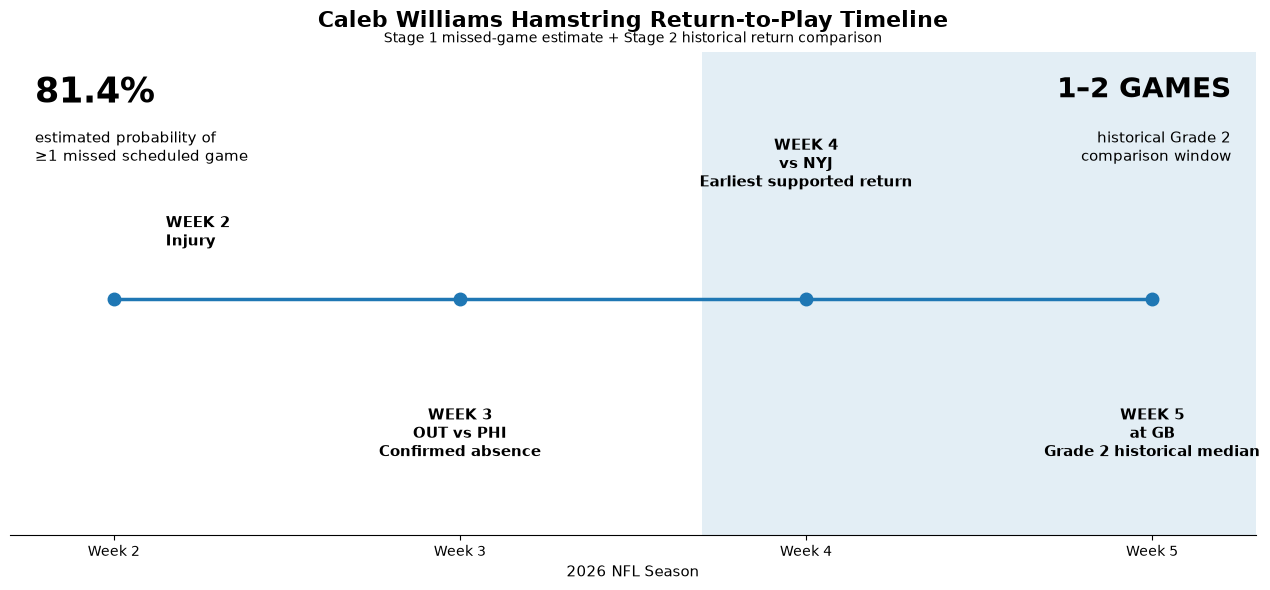

Saved visualization to: ../visualizations/caleb_williams_rtp_timeline.png


In [51]:
# Step 36 — visualize Caleb's final RTP estimate

import matplotlib.pyplot as plt
from pathlib import Path

viz_dir = Path("../visualizations")
viz_dir.mkdir(exist_ok=True)

# Timeline
weeks = [2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(13, 6))

# Main timeline
ax.plot(
    weeks,
    [1, 1, 1, 1],
    marker="o",
    markersize=9,
    linewidth=2.5
)

# Historical Grade 2 return window
ax.axvspan(
    3.7,
    5.3,
    alpha=0.12
)

# Event labels
ax.annotate(
    "WEEK 2\nInjury",
    xy=(2, 1),
    xytext=(2.15, 1.045),
    ha="left",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.annotate(
    "WEEK 3\nOUT vs PHI\nConfirmed absence",
    xy=(3, 1),
    xytext=(3, 0.90),
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold"
)

ax.annotate(
    "WEEK 4\nvs NYJ\nEarliest supported return",
    xy=(4, 1),
    xytext=(4, 1.10),
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

ax.annotate(
    "WEEK 5\nat GB\nGrade 2 historical median",
    xy=(5, 1),
    xytext=(5, 0.90),
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold"
)

# Stage 1 probability callout
ax.text(
    0.02,
    0.95,
    "81.4%",
    transform=ax.transAxes,
    fontsize=25,
    fontweight="bold",
    va="top"
)

ax.text(
    0.02,
    0.84,
    "estimated probability of\n≥1 missed scheduled game",
    transform=ax.transAxes,
    fontsize=11,
    va="top"
)

# Stage 2 callout
ax.text(
    0.98,
    0.95,
    "1–2 GAMES",
    transform=ax.transAxes,
    fontsize=20,
    fontweight="bold",
    ha="right",
    va="top"
)

ax.text(
    0.98,
    0.84,
    "historical Grade 2\ncomparison window",
    transform=ax.transAxes,
    fontsize=11,
    ha="right",
    va="top"
)

# Title and subtitle
ax.set_title(
    "Caleb Williams Hamstring Return-to-Play Timeline",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.02,
    "Stage 1 missed-game estimate + Stage 2 historical return comparison",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

# Axis formatting
ax.set_xticks(weeks)
ax.set_xticklabels(["Week 2", "Week 3", "Week 4", "Week 5"])
ax.set_xlabel("2026 NFL Season", fontsize=11)

ax.set_yticks([])
ax.set_ylim(0.78, 1.23)
ax.set_xlim(1.7, 5.3)

# Remove unnecessary borders
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()

# Save over existing visualization
output_path = viz_dir / "caleb_williams_rtp_timeline.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved visualization to:", output_path)

In [47]:
# Step 37 — save final Caleb RTP results

final_results = pd.DataFrame({
    "player": ["Caleb Williams"],
    "injury": ["Grade 2 right hamstring strain"],
    "injury_week": [2],

    "stage1_miss_probability": [
        round(caleb_miss_prob, 3)
    ],

    "confirmed_missed_game": [
        "Week 3 vs PHI"
    ],

    "historical_rtp_window_games": [
        "1-2"
    ],

    "grade2_comparison_n": [
        len(grade2_comps)
    ],

    "grade2_median_games_missed": [
        grade2_comps["rtp_games_missed"].median()
    ],

    "earliest_supported_return": [
        "Week 4 vs NYJ"
    ],

    "grade2_center_return": [
        "Week 5 at GB"
    ]
})

results_path = Path("../data/caleb_williams_rtp_estimate.csv")

final_results.to_csv(results_path, index=False)

print(final_results.to_string(index=False))
print("\nSaved results to:", results_path)

        player                         injury  injury_week  stage1_miss_probability confirmed_missed_game historical_rtp_window_games  grade2_comparison_n  grade2_median_games_missed earliest_supported_return grade2_center_return
Caleb Williams Grade 2 right hamstring strain            2                    0.814         Week 3 vs PHI                         1-2                    3                         2.0             Week 4 vs NYJ         Week 5 at GB

Saved results to: ../data/caleb_williams_rtp_estimate.csv


## Final Return-to-Play Estimate

This analysis used a two-stage framework to evaluate Caleb Williams' 2026 right hamstring injury.

### Stage 1 — Probability of Missing a Game
A regularized logistic regression model trained on historical NFL quarterback hamstring episodes estimated an **81.4% probability that the injury would result in at least one missed scheduled game**. Caleb was subsequently ruled out for Chicago's Week 3 game against Philadelphia, providing an observed outcome against which the Stage 1 estimate can be evaluated.

### Stage 2 — Return-to-Play Window
Among historical quarterback hamstring episodes with an observed return to play, the median absence was **1 game**. The smaller subgroup of three documented Grade 2 / moderate injuries had an observed range of **1–2 games missed**, with a median of **2 games**.

Mapped onto Chicago's 2026 schedule:

- **Week 3 vs. PHI:** Confirmed absence
- **Week 4 vs. NYJ:** Earliest return supported by the historical comparison window
- **Week 5 at GB:** Corresponds to the median of the Grade 2 comparison group

Therefore, the historical evidence supports **Week 4–Week 5 as the primary return-to-play window**, rather than a single predicted return date.

### Interpretation

The Stage 1 probability and Stage 2 return window answer different questions. Stage 1 estimates whether an injury episode is associated with missing at least one scheduled game, while Stage 2 describes the duration of absence among comparable historical cases.

Because the historical sample is small—particularly the Grade 2 comparison group—these results should be interpreted as an **exploratory data-driven estimate rather than a clinical prognosis or calibrated probability of an exact return date**.